# Observed SOH Feature Engineering

This notebook rewrites the old feature-engineering workflow around one goal: build a model-ready shortlist of features most relevant to forecasting **observed SOH**.

What it does:
- loads the latent/event table used by the forecast notebooks
- builds regular operating features, latent-state features, physics-stress proxies, static/categorical features, existing history features, and multiscale lag/window features
- ranks those candidates on the `train` split against `next_observed_soh_pct` and `next_observed_delta_pct`
- prunes redundant features
- saves a selected feature bundle under `ml_workspace/soh_forecast/output/feature_engineering_observed`
- runs a quick ridge validation to check whether the selected shortlist is useful

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "ml_workspace").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not locate repo root")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ml_workspace.soh_forecast.common import set_seed
from ml_workspace.soh_forecast.feature_pipeline import (
    add_forecast_features,
    add_multiscale_history_features,
    assign_shared_splits,
    available_feature_sets,
    load_latent_dataset,
    split_frames_from_assigned,
)
from ml_workspace.soh_forecast.feature_selection import (
    build_static_dummies,
    feature_name_metadata,
    rank_features_by_correlation,
    save_selected_feature_bundle,
    select_feature_subset,
    summarize_selection_by_family,
)

set_seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 240)

PRIMARY_PLANE = "166"
HOLDOUT_PLANE = "192"
RUN_LATENT_PIPELINE = False
RT_PROFILE = "balanced"
Q_DAY_SIGMA_PCT = 0.05
COMPARE_BACKEND = True
TRAIN_FRAC = 0.70
VALID_FRAC = 0.15

LAG_STEPS = (1, 2, 3, 5, 8, 13)
ROLLING_WINDOWS = (2, 3, 5, 8, 13, 21)
EWM_SPANS = (3, 5, 8, 13)
RATE_STEPS = (1, 3, 5)

TOP_K_TOTAL = 70
MAX_PER_FAMILY = 20
MIN_COMBINED_SCORE = 0.035
MAX_PAIRWISE_CORR = 0.92

OUTPUT_DIR = REPO_ROOT / "ml_workspace" / "soh_forecast" / "output" / "feature_engineering_observed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Output dir:", OUTPUT_DIR)

Repo root: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane
Output dir: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_forecast/output/feature_engineering_observed


## Load and build candidate feature space

In [2]:
latent_df, summaries = load_latent_dataset(
    repo_root=REPO_ROOT,
    primary_plane=PRIMARY_PLANE,
    holdout_plane=HOLDOUT_PLANE,
    run_latent_pipeline=RUN_LATENT_PIPELINE,
    rt_profile=RT_PROFILE,
    q_day_sigma_pct=Q_DAY_SIGMA_PCT,
)
forecast_df = add_forecast_features(latent_df)
forecast_df, multiscale_cols = add_multiscale_history_features(
    forecast_df,
    lag_steps=LAG_STEPS,
    rolling_windows=ROLLING_WINDOWS,
    ewm_spans=EWM_SPANS,
    rate_steps=RATE_STEPS,
)

shared_df = assign_shared_splits(
    forecast_df,
    primary_plane=PRIMARY_PLANE,
    holdout_plane=HOLDOUT_PLANE,
    train_frac=TRAIN_FRAC,
    valid_frac=VALID_FRAC,
    required_target_cols=["next_observed_soh_pct", "next_observed_delta_pct"],
)
shared_df, static_dummy_cols = build_static_dummies(shared_df, ["plane_id", "battery_id_str", "event_type"])
splits = split_frames_from_assigned(shared_df)
feature_groups = available_feature_sets(shared_df)
feature_groups["multiscale_history"] = [col for col in multiscale_cols if col in shared_df.columns]
feature_groups["static_dummies"] = static_dummy_cols

display(pd.DataFrame(list(summaries.values())))
display(pd.DataFrame([{"group": key, "n_features": len(value)} for key, value in feature_groups.items()]))
display(shared_df.groupby(["split", "plane_id", "battery_id"], as_index=False).size().rename(columns={"size": "rows"}))
print("Total rows in shared feature table:", len(shared_df))
print("Train rows used for ranking:", len(splits.train))

/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_forecast/feature_pipeline.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g["degradation_stress_proxy"] = (
/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_forecast/feature_pipeline.py:438: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g["rolling_stress_index_mean_5"] = g["instant_stress_index"].shift(1).rolling(5, min_periods=1).mean()
/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_forecast/feature_p

,plane_id,rt_profile,battery_ids_processed,n_events_total,n_events_per_battery,n_events_dropped_missing_observed_soh,sigma_base_pct_per_battery,q_day_sigma_pct,raw_total_variation_per_battery,smoothed_total_variation_per_battery,raw_max_upward_jump_pct_per_battery,smoothed_max_upward_jump_pct_per_battery,fraction_events_with_condition_multiplier_gt_3,notes
0,166,balanced,"[1, 2]",1106,"{'1': 553, '2': 553}",0,"{'1': 0.55, '2': 0.55}",0.05,"{'1': 484.0, '2': 469.0}","{'1': 51.14722851352783, '2': 49.6942665930803}","{'1': 29.0, '2': 25.0}","{'1': 1.0244025838651254, '2': 1.0229620160775...","{'1': 0.2766726943942134, '2': 0.2567811934900...",FilterPy latent SOH is the canonical output. P...
1,192,balanced,"[1, 2]",98,"{'1': 49, '2': 49}",0,"{'1': 0.55, '2': 0.55}",0.05,"{'1': 5.0, '2': 5.0}","{'1': 0.8559490722647354, '2': 0.7980700292446...","{'1': 0.0, '2': 0.0}","{'1': -1.2547329788503703e-06, '2': -1.1689867...","{'1': 0.10204081632653061, '2': 0.102040816326...",FilterPy latent SOH is the canonical output. P...


,group,n_features
0,raw,21
1,operating,34
2,latent,7
3,physics,16
4,static_numeric,5
5,static_categorical,3
6,history,35
7,multiscale_history,1272
8,static_dummies,7


,split,plane_id,battery_id,rows
0,holdout,192,1,48
1,holdout,192,2,48
2,test,166,1,83
3,test,166,2,82
4,train,166,1,387
5,train,166,2,386
6,valid,166,1,82
7,valid,166,2,84


Total rows in shared feature table: 1200
Train rows used for ranking: 773


## Rank features for observed SOH relevance

The ranking is driven by the train split only. The combined score weights correlation to `next_observed_delta_pct` more heavily than correlation to `next_observed_soh_pct`, because raw next-level correlation is otherwise dominated by current SOH.

In [3]:
candidate_cols = list(dict.fromkeys(sum(feature_groups.values(), [])))
train_rank_df = rank_features_by_correlation(
    splits.train,
    feature_cols=candidate_cols,
    next_level_col="next_observed_soh_pct",
    delta_col="next_observed_delta_pct",
    min_non_null=25,
)
selected_df = select_feature_subset(
    splits.train,
    train_rank_df,
    top_k_total=TOP_K_TOTAL,
    max_per_family=MAX_PER_FAMILY,
    min_combined_score=MIN_COMBINED_SCORE,
    max_pairwise_corr=MAX_PAIRWISE_CORR,
)
family_summary_df = summarize_selection_by_family(selected_df)
metadata_df = feature_name_metadata(selected_df["feature"].tolist())

display(train_rank_df.head(30).round(4))
display(selected_df.head(40).round(4))
display(family_summary_df.round(4))
display(metadata_df.head(20))

print("Selected feature count:", len(selected_df))

,feature,family,non_null_rows,missing_frac,n_unique,pearson_next_level,spearman_next_level,pearson_next_delta,spearman_next_delta,combined_score
0,observed_soh_pct,operating,773,0.0000,36,0.9705,0.9690,-0.1256,-0.1383,0.3423
1,observed_soh_pct_lag1,history,771,0.0026,36,0.9476,0.9454,-0.0973,-0.1141,0.3171
2,prev_observed_soh_pct,history,771,0.0026,36,0.9476,0.9454,-0.0973,-0.1141,0.3171
3,observed_soh_pct_rollmean_2,history,771,0.0026,70,0.9427,0.9395,-0.1005,-0.1134,0.3164
4,observed_soh_pct_rollmin_2,history,771,0.0026,36,0.9367,0.9329,-0.0997,-0.1157,0.3156
5,observed_soh_pct_ewmmean_3,history,771,0.0026,766,0.9415,0.9362,-0.0990,-0.1136,0.3154
6,rolling_observed_soh_mean_3,history,771,0.0026,104,0.9364,0.9317,-0.0981,-0.1159,0.3150
7,observed_soh_pct_rollmean_3,history,771,0.0026,104,0.9364,0.9317,-0.0981,-0.1159,0.3150
8,observed_soh_pct_rollmin_3,history,771,0.0026,36,0.9246,0.9191,-0.0997,-0.1193,0.3139
9,observed_soh_pct_rollmax_2,history,771,0.0026,36,0.9366,0.9358,-0.0999,-0.1097,0.3134


,feature,family,non_null_rows,missing_frac,n_unique,pearson_next_level,spearman_next_level,pearson_next_delta,spearman_next_delta,combined_score
0,observed_soh_pct,operating,773,0.0000,36,0.9705,0.9690,-0.1256,-0.1383,0.3423
1,observed_soh_pct_rollmin_5,history,771,0.0026,36,0.9054,0.8933,-0.0925,-0.1097,0.3016
2,observed_soh_pct_rollmax_13,history,771,0.0026,31,0.8419,0.8620,-0.1126,-0.1121,0.2977
3,latent_soh_filterpy_filter_pct,latent,773,0.0000,773,0.7954,0.7967,-0.0586,-0.0421,0.2356
4,cumulative_event_count,operating,773,0.0000,387,-0.7204,-0.7227,0.0053,-0.0281,0.1947
5,latent_filter_delta_1,latent,771,0.0026,771,0.3510,0.3636,-0.0790,-0.1739,0.1916
6,current_temp_stress_index_ewmstd_13,physics,773,0.0000,752,0.4699,0.4356,-0.0094,-0.0724,0.1477
7,current_temp_stress_index_rollmax_13,physics,771,0.0026,117,0.4098,0.3462,-0.0294,-0.0997,0.1466
8,current_temp_stress_index_rollstd_13,physics,773,0.0000,768,0.4122,0.3296,-0.0296,-0.1022,0.1455
9,duration_stress_index_rollmax_21,physics,771,0.0026,80,-0.3778,-0.3884,0.0159,0.0880,0.1404


,family,n_selected,mean_score,max_score
0,physics,14,0.1334,0.1477
1,operating,12,0.1183,0.3423
2,latent,5,0.1547,0.2356
3,static_categorical,3,0.0389,0.0429
4,history,2,0.2997,0.3016


,feature,family,lag_step,roll_window,ewm_span,rate_step
0,observed_soh_pct,operating,NaN,NaN,NaN,NaN
1,observed_soh_pct_rollmin_5,history,NaN,5.0,NaN,NaN
2,observed_soh_pct_rollmax_13,history,NaN,13.0,NaN,NaN
3,latent_soh_filterpy_filter_pct,latent,NaN,NaN,NaN,NaN
4,cumulative_event_count,operating,NaN,NaN,NaN,NaN
5,latent_filter_delta_1,latent,NaN,NaN,NaN,NaN
6,current_temp_stress_index_ewmstd_13,physics,NaN,NaN,13.0,NaN
7,current_temp_stress_index_rollmax_13,physics,NaN,13.0,NaN,NaN
8,current_temp_stress_index_rollstd_13,physics,NaN,13.0,NaN,NaN
9,duration_stress_index_rollmax_21,physics,NaN,21.0,NaN,NaN


Selected feature count: 36


## Visualize selected feature mix

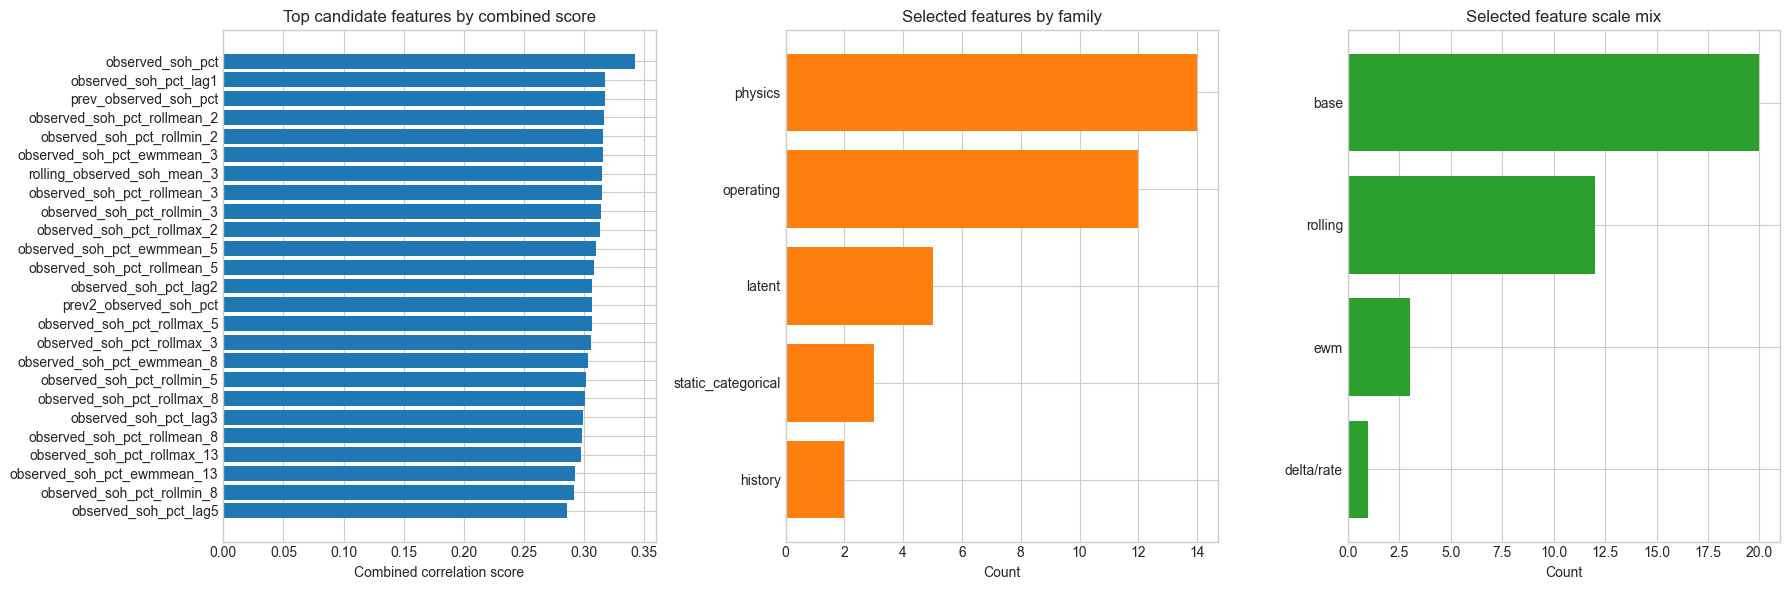

In [4]:
top_plot_df = train_rank_df.head(25).sort_values("combined_score")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].barh(top_plot_df["feature"], top_plot_df["combined_score"], color="#1f77b4")
axes[0].set_title("Top candidate features by combined score")
axes[0].set_xlabel("Combined correlation score")

family_plot_df = family_summary_df.sort_values("n_selected")
axes[1].barh(family_plot_df["family"], family_plot_df["n_selected"], color="#ff7f0e")
axes[1].set_title("Selected features by family")
axes[1].set_xlabel("Count")

freq_df = metadata_df.copy()
freq_df["dominant_scale"] = np.where(freq_df["roll_window"].notna(), "rolling", np.where(freq_df["ewm_span"].notna(), "ewm", np.where(freq_df["lag_step"].notna(), "lag", np.where(freq_df["rate_step"].notna(), "delta/rate", "base"))))
scale_plot_df = freq_df.groupby("dominant_scale", as_index=False).size().sort_values("size")
axes[2].barh(scale_plot_df["dominant_scale"], scale_plot_df["size"], color="#2ca02c")
axes[2].set_title("Selected feature scale mix")
axes[2].set_xlabel("Count")

fig.tight_layout()

## Quick validation check

This is not the main benchmark notebook. It is a sanity check that the selected shortlist is useful versus a broad raw baseline on the same observed-SOH target.

In [5]:
def fit_best_ridge(X_train, y_train, X_valid, y_valid):
    best_model = None
    best_mae = np.inf
    for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train)
        mae = mean_absolute_error(y_valid, model.predict(X_valid))
        if mae < best_mae:
            best_mae = mae
            best_model = model
    return best_model


def evaluate_feature_list(feature_list: list[str], name: str) -> dict[str, float]:
    cols = [col for col in feature_list if col in shared_df.columns]
    train_X = splits.train[cols].apply(pd.to_numeric, errors="coerce")
    valid_X = splits.valid[cols].apply(pd.to_numeric, errors="coerce")
    test_X = splits.test[cols].apply(pd.to_numeric, errors="coerce")
    medians = train_X.median().fillna(0.0)
    train_X = train_X.fillna(medians).fillna(0.0)
    valid_X = valid_X.fillna(medians).fillna(0.0)
    test_X = test_X.fillna(medians).fillna(0.0)

    scaler = StandardScaler()
    train_Xs = scaler.fit_transform(train_X)
    valid_Xs = scaler.transform(valid_X)
    test_Xs = scaler.transform(test_X)

    y_train_delta = splits.train["next_observed_delta_pct"].to_numpy(dtype=float)
    y_valid_delta = splits.valid["next_observed_delta_pct"].to_numpy(dtype=float)
    y_test_level = splits.test["next_observed_soh_pct"].to_numpy(dtype=float)
    current_test = splits.test["observed_soh_pct"].to_numpy(dtype=float)

    model = fit_best_ridge(train_Xs, y_train_delta, valid_Xs, y_valid_delta)
    pred_test_delta = model.predict(test_Xs)
    pred_test_level = current_test + pred_test_delta
    return {
        "feature_set": name,
        "n_features": len(cols),
        "test_level_mae": float(mean_absolute_error(y_test_level, pred_test_level)),
        "test_level_rmse": float(np.sqrt(mean_squared_error(y_test_level, pred_test_level))),
    }


baseline_features = list(dict.fromkeys(feature_groups["raw"] + feature_groups["operating"] + feature_groups["physics"] + feature_groups["static_numeric"] + feature_groups["static_dummies"]))
selected_features = selected_df["feature"].tolist()

validation_results = pd.DataFrame(
    [
        evaluate_feature_list(baseline_features, "baseline_raw_operating_physics_static"),
        evaluate_feature_list(selected_features, "selected_shortlist"),
    ]
)
display(validation_results.round(4))

,feature_set,n_features,test_level_mae,test_level_rmse
0,baseline_raw_operating_physics_static,65,1.6913,4.1567
1,selected_shortlist,36,1.7099,3.8033


## Save model-ready feature bundle

In [6]:
save_selected_feature_bundle(
    output_dir=OUTPUT_DIR,
    ranked_df=train_rank_df,
    selected_df=selected_df,
    feature_groups=feature_groups,
)
metadata_df.to_csv(OUTPUT_DIR / "selected_feature_metadata.csv", index=False)
validation_results.to_csv(OUTPUT_DIR / "selected_feature_validation.csv", index=False)
shared_df.to_csv(OUTPUT_DIR / "observed_feature_search_table.csv", index=False)

print("Saved feature-engineering outputs to", OUTPUT_DIR)
print("Primary model-ready feature list file:", OUTPUT_DIR / "selected_features.txt")

Saved feature-engineering outputs to /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_forecast/output/feature_engineering_observed
Primary model-ready feature list file: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_forecast/output/feature_engineering_observed/selected_features.txt


## Interpretation notes

Use `selected_features.txt` or `selected_candidate_features.csv` as the shortlist for the model-comparison notebooks or Python runner.

How to read the output:
- `ranked_candidate_features.csv`: full search space ranked by observed-SOH relevance
- `selected_candidate_features.csv`: pruned shortlist after family caps and pairwise-correlation pruning
- `selected_feature_family_summary.csv`: how much of the shortlist came from operating, physics, static, latent, or history groups
- `selected_feature_validation.csv`: quick ridge sanity check that the shortlist is competitive